<a href="https://colab.research.google.com/github/PraeThipwarin/Optimization/blob/main/GA_Optimization_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Genetic Algorithm for Optimization
## วิชา Optimization | Asst. Prof. Paskorn Champrasert
### Computer Engineering, Chiang Mai University

---

## 📌 โจทย์ปัญหา (Problem Statement)

**Maximize:**
$$f(x_1, x_2) = 2x_1 + 3x_2$$

**Subject to:**
$$0.5x_1 + 0.2x_2 \leq 10$$
$$x_1 + x_2 \leq 30$$
$$0 \leq x_1 \leq 31$$
$$0 \leq x_2 \leq 31$$

---

## 🔑 แนวคิดของ Genetic Algorithm (GA)

GA เป็นอัลกอริทึมค้นหาคำตอบที่ได้แรงบันดาลใจจากวิวัฒนาการทางชีววิทยา โดยมีขั้นตอนหลัก ดังนี้:

1. **Initialization** → สร้างประชากร (Population) เริ่มต้นแบบสุ่ม
2. **Fitness Evaluation** → ประเมินคุณภาพของแต่ละ Individual
3. **Parent Selection** → เลือก Parent ที่ดีสำหรับการสืบพันธุ์
4. **Crossover (Xover)** → ผสมพันธุ์เพื่อสร้าง Offspring ใหม่
5. **Mutation** → กลายพันธุ์เพื่อเพิ่มความหลากหลาย
6. **Population Selection** → เลือก Individual ที่ดีที่สุดสำหรับรุ่นถัดไป
7. **วนซ้ำ** จนครบ Generation ที่กำหนด

---

## 📦 ส่วนที่ 1: Import Libraries

In [1]:
import random          # สำหรับการสุ่มค่าต่างๆ
import numpy as np     # สำหรับการคำนวณทางคณิตศาสตร์
import matplotlib.pyplot as plt  # สำหรับการแสดงกราฟ

# กำหนด seed เพื่อให้ผลลัพธ์ reproducible (สามารถ comment ออกได้เพื่อดูผลที่แตกต่างกัน)
random.seed(42)
np.random.seed(42)

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


## ⚙️ ส่วนที่ 2: กำหนด Parameters ของ GA

| Parameter | ค่า | ความหมาย |
|-----------|-----|-----------|
| `POP_SIZE` | 20 | จำนวน Individual ใน Population |
| `N_BITS` | 5 | จำนวน bit ต่อตัวแปร 1 ตัว |
| `CHROMOSOME_LEN` | 10 | ความยาว Chromosome ทั้งหมด (x1=5 bits + x2=5 bits) |
| `XOVER_RATE` | 0.8 | สัดส่วน Offspring ที่สร้างในแต่ละ Generation |
| `MUTATION_RATE` | 1/5 | โอกาสที่แต่ละ bit จะ flip |
| `GENERATION_MAX` | 100 | จำนวนรอบสูงสุดที่วน |
| `ELITE_RATE` | 0.2 | สัดส่วน Elite ที่นำมาจาก Parent Population |
| `PENALTY_WEIGHT` | 100 | น้ำหนักโทษสำหรับ constraint ที่ละเมิด |

In [ ]:
# ============================================================
# GA Parameters
# ============================================================

POP_SIZE       = 100      # เพิ่ม Population เพื่อค้นหาในพื้นที่ที่กว้างระดับแสน
N_VARS         = 4        # ตัวแปร 4 ตัว (x1: Bonds, x2: Mortgages, x3: Car Loans, x4: Personal Loans)
# ไม่ต้องใช้ N_BITS เพราะเปลี่ยนเป็น Real-Valued Encoding

XOVER_RATE     = 0.8
INITIAL_MUTATION_RATE = 0.2  # เปลี่ยนมาใช้ระบบ Adaptive Mutation
GENERATION_MAX = 300
ELITE_RATE     = 0.2
PENALTY_WEIGHT = 500      # ค่าน้ำหนัก Penalty

N_OFFSPRING    = int(POP_SIZE * XOVER_RATE)
N_ELITE        = POP_SIZE - N_OFFSPRING

print(f"   GA Parameters Summary")
print(f"   Population Size   : {POP_SIZE}")
print(f"   Crossover Rate    : {XOVER_RATE} → {N_OFFSPRING} Offspring per Generation")
print(f"   Mutation Rate     : {MUTATION_RATE:.4f} (1/{N_BITS})")
print(f"   Elite Count       : {N_ELITE} individuals from Parent Population")
print(f"   Max Generations   : {GENERATION_MAX}")
print(f"   Penalty Weight    : {PENALTY_WEIGHT}")

   GA Parameters Summary
   Population Size   : 20
   Chromosome Length : 10 bits (x1=5bits + x2=5bits)
   Crossover Rate    : 0.8 → 16 Offspring per Generation
   Mutation Rate     : 0.2000 (1/5)
   Elite Count       : 4 individuals from Parent Population
   Max Generations   : 100
   Penalty Weight    : 100


## 🔢 ส่วนที่ 3: Encoding / Decoding Function

### Binary Encoding
แต่ละตัวแปร (x1, x2) จะถูกแทนด้วย **5 bits**
- `00000` = 0
- `00001` = 1
- `11111` = 31

**Chromosome** (10 bits): `[bit4 bit3 bit2 bit1 bit0 | bit4 bit3 bit2 bit1 bit0]`
                                        ↑ x1 (5 bits)  ↑ x2 (5 bits)

**ตัวอย่าง:**
- x1 = 10 → binary = `01010`
- x2 = 20 → binary = `10100`
- Chromosome = `[0, 1, 0, 1, 0, 1, 0, 1, 0, 0]`

In [ ]:
def encode(x1, x2, n_bits=N_BITS):
    """
    แปลงค่าตัวแปร x1, x2 ให้เป็น Binary Chromosome

    Parameters:
        x1 (int): ค่าตัวแปรแรก (0-31)
        x2 (int): ค่าตัวแปรที่สอง (0-31)
        n_bits (int): จำนวน bits ต่อตัวแปร

    Returns:
        list: Chromosome แบบ binary [b1, b2, ..., b10]
    """
    # แปลง x1 เป็น binary list ขนาด n_bits
    # format(x1, f'0{n_bits}b') แปลง x1 เป็น string binary เช่น '01010'
    x1_bits = [int(b) for b in format(int(x1), f'0{n_bits}b')]
    x2_bits = [int(b) for b in format(int(x2), f'0{n_bits}b')]

    # รวม bits ของ x1 และ x2 เป็น Chromosome เดียว
    chromosome = x1_bits + x2_bits
    return chromosome


def decode(chromosome, n_bits=N_BITS):
    """
    แปลง Binary Chromosome กลับเป็นค่าตัวแปร x1, x2

    Parameters:
        chromosome (list): Chromosome แบบ binary
        n_bits (int): จำนวน bits ต่อตัวแปร

    Returns:
        tuple: (x1, x2) เป็นค่าจำนวนเต็ม
    """
    # แยก bits ของ x1 และ x2 ออกจาก Chromosome
    x1_bits = chromosome[:n_bits]   # 5 bits แรก = x1
    x2_bits = chromosome[n_bits:]   # 5 bits หลัง = x2

    # แปลง binary list เป็นเลขฐาน 10
    # int(''.join(map(str, bits)), 2) แปลง ['0','1','0','1','0'] → '01010' → 10
    x1 = int(''.join(map(str, x1_bits)), 2)
    x2 = int(''.join(map(str, x2_bits)), 2)

    return x1, x2


# ==========================================
# ทดสอบ Encoding / Decoding
# ==========================================
print("ทดสอบ Encoding / Decoding")
print("-" * 45)

test_cases = [(0, 0), (31, 31), (10, 20), (15, 7)]
for x1, x2 in test_cases:
    chrom = encode(x1, x2)
    decoded_x1, decoded_x2 = decode(chrom)
    print(f"  x1={x1:2d}, x2={x2:2d}  →  Chromosome: {chrom}")
    print(f"  {'':18}  →  Decoded: x1={decoded_x1}, x2={decoded_x2}")
    print()

ทดสอบ Encoding / Decoding
---------------------------------------------
  x1= 0, x2= 0  →  Chromosome: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
                      →  Decoded: x1=0, x2=0

  x1=31, x2=31  →  Chromosome: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
                      →  Decoded: x1=31, x2=31

  x1=10, x2=20  →  Chromosome: [0, 1, 0, 1, 0, 1, 0, 1, 0, 0]
                      →  Decoded: x1=10, x2=20

  x1=15, x2= 7  →  Chromosome: [0, 1, 1, 1, 1, 0, 0, 1, 1, 1]
                      →  Decoded: x1=15, x2=7



##  ส่วนที่ 4: Fitness Function

### สูตรคำนวณ Fitness
$$\text{Fitness} = f(x_1, x_2) - W \cdot \sum_{i} \max(0, \text{violation}_i)$$

โดย:
- $f(x_1, x_2) = 2x_1 + 3x_2$ คือ Objective Function
- $W = 100$ คือ Penalty Weight
- violation คือปริมาณที่ละเมิด constraint

### Constraints ที่ตรวจสอบ:
1. $0.5x_1 + 0.2x_2 - 10 \leq 0$ → violation = $\max(0, 0.5x_1 + 0.2x_2 - 10)$
2. $x_1 + x_2 - 30 \leq 0$ → violation = $\max(0, x_1 + x_2 - 30)$

In [ ]:
def calculate_fitness(chromosome, penalty_weight=PENALTY_WEIGHT):
    """
    คำนวณค่า Fitness ของ Individual

    Fitness = Objective Value - Penalty จาก Constraint Violations

    Parameters:
        chromosome (list): Binary chromosome
        penalty_weight (float): น้ำหนักของ Penalty (W=100)

    Returns:
        float: ค่า Fitness (ยิ่งสูงยิ่งดี)
    """
    # --- Step 1: Decode chromosome เพื่อรับค่า x1, x2 ---
    x1, x2 = decode(chromosome)

    # --- Step 2: คำนวณ Objective Function Value ---
    # นี่คือค่าที่เราต้องการ Maximize
    objective_value = 2 * x1 + 3 * x2

    # --- Step 3: คำนวณ Penalty จาก Constraint Violations ---
    # ถ้า constraint ไม่ถูกละเมิด → violation = 0 → ไม่มี penalty
    # ถ้า constraint ถูกละเมิด → violation > 0 → มี penalty

    # Constraint 1: 0.5*x1 + 0.2*x2 <= 10
    violation_c1 = max(0, 0.5 * x1 + 0.2 * x2 - 10)

    # Constraint 2: x1 + x2 <= 30
    violation_c2 = max(0, x1 + x2 - 30)

    # รวม Penalty ทั้งหมด (น้ำหนัก * ผลรวมการละเมิด)
    total_penalty = penalty_weight * (violation_c1 + violation_c2)

    # --- Step 4: คำนวณ Fitness สุดท้าย ---
    fitness = objective_value - total_penalty

    return fitness


# ==========================================
# ทดสอบ Fitness Function
# ==========================================
print("ทดสอบ Fitness Function")
print("-" * 55)

test_solutions = [
    (0,  30, "ละเมิด C2: x1+x2=30 ✅, C1: 0+6=6 ✅"),
    (10, 20, "C1: 5+4=9 ✅, C2: 30 ✅"),
    (20, 10, "C1: 10+2=12 ❌ละเมิด"),
    (0,  31, "C2: 31 ❌ละเมิด"),
    (4,  20, "C1: 2+4=6 ✅, C2: 24 ✅"),
]

for x1, x2, note in test_solutions:
    chrom = encode(x1, x2)
    fit = calculate_fitness(chrom)
    obj = 2*x1 + 3*x2
    print(f"  x1={x1:2d}, x2={x2:2d} → Obj={obj:4.0f}, Fitness={fit:7.2f}  ({note})")

ทดสอบ Fitness Function
-------------------------------------------------------
  x1= 0, x2=30 → Obj=  90, Fitness=  90.00  (ละเมิด C2: x1+x2=30 ✅, C1: 0+6=6 ✅)
  x1=10, x2=20 → Obj=  80, Fitness=  80.00  (C1: 5+4=9 ✅, C2: 30 ✅)
  x1=20, x2=10 → Obj=  70, Fitness=-130.00  (C1: 10+2=12 ❌ละเมิด)
  x1= 0, x2=31 → Obj=  93, Fitness=  -7.00  (C2: 31 ❌ละเมิด)
  x1= 4, x2=20 → Obj=  68, Fitness=  68.00  (C1: 2+4=6 ✅, C2: 24 ✅)


## 🏗️ ส่วนที่ 5: Population Initialization

สร้าง Population เริ่มต้นด้วยการสุ่ม Chromosome แบบ Binary
แต่ละ Individual เป็น list ของ 0 และ 1 ขนาด 10 bits

In [ ]:
def initialize_population(pop_size=POP_SIZE, chrom_len=CHROMOSOME_LEN):
    """
    สร้าง Population เริ่มต้นแบบสุ่ม

    Parameters:
        pop_size (int): จำนวน Individual ใน Population
        chrom_len (int): ความยาว Chromosome

    Returns:
        list: Population ที่เป็น list ของ Chromosomes
    """
    population = []
    for _ in range(pop_size):
        # สุ่ม 0 หรือ 1 สำหรับแต่ละ bit ใน Chromosome
        chromosome = [random.randint(0, 1) for _ in range(chrom_len)]
        population.append(chromosome)
    return population


# ==========================================
# สร้าง Initial Population
# ==========================================
population = initialize_population()

print("🏗️ Initial Population (แสดง 5 ตัวแรก)")
print("-" * 60)
print(f"{'#':>3} | {'Chromosome':^22} | {'x1':>4} | {'x2':>4} | {'Fitness':>8}")
print("-" * 60)

for i, chrom in enumerate(population[:5]):
    x1, x2 = decode(chrom)
    fit = calculate_fitness(chrom)
    chrom_str = ''.join(map(str, chrom))
    # แสดง chromosome แบบแยก x1|x2
    print(f"  {i+1:1d} | {chrom_str[:5]}|{chrom_str[5:]} | {x1:4d} | {x2:4d} | {fit:8.2f}")

print(f"\n Population ทั้งหมด: {len(population)} individuals")

🏗️ Initial Population (แสดง 5 ตัวแรก)
------------------------------------------------------------
  # |       Chromosome       |   x1 |   x2 |  Fitness
------------------------------------------------------------
  1 | 00100|00010 |    4 |    2 |    14.00
  2 | 00000|01011 |    0 |   11 |    33.00
  3 | 00111|00100 |    7 |    4 |    26.00
  4 | 10111|01010 |   23 |   10 |  -574.00
  5 | 11000|01000 |   24 |    8 |  -488.00

 Population ทั้งหมด: 20 individuals


##  ส่วนที่ 6: Parent Selection — Binary Tournament

### หลักการ Binary Tournament Selection
1. สุ่มเลือก **Candidate 2 ตัว** จาก Population
2. ตัวที่มี **Fitness สูงกว่า** จะได้เป็น Parent
3. ทำซ้ำ **2 รอบ** เพื่อได้ **Parent1** และ **Parent2**

```
Population:  [A] [B] [C] [D] [E] ...
                   ↓ สุ่ม 2 ตัว
Tournament 1: [B] vs [D]  →  fitness(B) > fitness(D)  →  Parent1 = B
Tournament 2: [A] vs [E]  →  fitness(E) > fitness(A)  →  Parent2 = E
```

In [ ]:
def parent_selection(population):
    """
    เลือก Parent 2 ตัว ด้วยวิธี Binary Tournament Selection

    กระบวนการ:
    - รอบที่ 1: สุ่ม 2 candidates → เปรียบ fitness → winner = Parent1
    - รอบที่ 2: สุ่ม 2 candidates → เปรียบ fitness → winner = Parent2

    Parameters:
        population (list): Population ปัจจุบัน

    Returns:
        tuple: (parent1, parent2) สอง Chromosomes ที่ถูกเลือก
    """
    def tournament(population):
        """Binary Tournament: สุ่ม 2 ตัว แล้วเลือกตัวที่ fitness ดีกว่า"""
        # สุ่มเลือก candidate 2 ตัว (ไม่ซ้ำกัน) จาก population
        candidates = random.sample(population, 2)
        candidate_a = candidates[0]
        candidate_b = candidates[1]

        # เปรียบเทียบ fitness และเลือกตัวที่ดีกว่า
        fitness_a = calculate_fitness(candidate_a)
        fitness_b = calculate_fitness(candidate_b)

        if fitness_a >= fitness_b:
            return candidate_a  # A ชนะ Tournament
        else:
            return candidate_b  # B ชนะ Tournament

    # ทำ Tournament 2 รอบ เพื่อได้ Parent 2 ตัว
    parent1 = tournament(population)
    parent2 = tournament(population)

    return parent1, parent2


# ==========================================
# ทดสอบ Parent Selection
# ==========================================
p1, p2 = parent_selection(population)
x1_p1, x2_p1 = decode(p1)
x1_p2, x2_p2 = decode(p2)

print("ทดสอบ Binary Tournament Selection")
print("-" * 50)
print(f"  Parent1: {p1}")
print(f"           x1={x1_p1}, x2={x2_p1}, Fitness={calculate_fitness(p1):.2f}")
print(f"  Parent2: {p2}")
print(f"           x1={x1_p2}, x2={x2_p2}, Fitness={calculate_fitness(p2):.2f}")

ทดสอบ Binary Tournament Selection
--------------------------------------------------
  Parent1: [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]
           x1=12, x2=15, Fitness=69.00
  Parent2: [0, 0, 1, 1, 1, 0, 0, 1, 0, 0]
           x1=7, x2=4, Fitness=26.00


##  ส่วนที่ 7: Crossover — One-Point Crossover

### หลักการ One-Point Crossover
1. สุ่มเลือก **จุดตัด (Crossover Point)** 1 จุด
2. **ไขว้** ส่วนหลังของ Chromosome

```
Parent1:  [1 0 1 | 0 1 1 0 1 0 0]
Parent2:  [0 1 0 | 1 0 0 1 0 1 1]
                ↑ Crossover Point = 3

Offspring1: [1 0 1 | 1 0 0 1 0 1 1]  ← ครึ่งแรกจาก P1, ครึ่งหลังจาก P2
Offspring2: [0 1 0 | 0 1 1 0 1 0 0]  ← ครึ่งแรกจาก P2, ครึ่งหลังจาก P1
```

In [ ]:
def crossover(parent1, parent2):
    """
    ทำ One-Point Crossover ระหว่าง Parent2 ตัว เพื่อสร้าง Offspring 2 ตัว

    กระบวนการ:
    1. สุ่มจุดตัด (crossover_point) ระหว่าง 1 ถึง len-1
    2. Offspring1 = ส่วนแรกของ P1 + ส่วนหลังของ P2
    3. Offspring2 = ส่วนแรกของ P2 + ส่วนหลังของ P1

    Parameters:
        parent1 (list): Chromosome ของ Parent1
        parent2 (list): Chromosome ของ Parent2

    Returns:
        tuple: (offspring1, offspring2) สอง Chromosomes ใหม่
    """
    chrom_len = len(parent1)

    # สุ่มจุดตัด ระหว่าง position 1 ถึง chrom_len-1
    # (ไม่รวม 0 และ chrom_len เพื่อให้แน่ใจว่ามีการแลกเปลี่ยน genes)
    crossover_point = random.randint(1, chrom_len - 1)

    # สร้าง Offspring โดยการไขว้ genes
    offspring1 = parent1[:crossover_point] + parent2[crossover_point:]
    offspring2 = parent2[:crossover_point] + parent1[crossover_point:]

    return offspring1, offspring2


# ==========================================
# ทดสอบ Crossover
# ==========================================
# สร้าง Parent ตัวอย่างชัดๆ เพื่อเห็นการทำงาน
test_p1 = encode(10, 5)   # x1=10 (01010), x2=5 (00101)
test_p2 = encode(3, 20)   # x1=3  (00011), x2=20 (10100)

off1, off2 = crossover(test_p1, test_p2)
x1_o1, x2_o1 = decode(off1)
x1_o2, x2_o2 = decode(off2)

print(" ทดสอบ One-Point Crossover")
print("-" * 55)
print(f"  Parent1  : {''.join(map(str, test_p1))}  (x1={decode(test_p1)[0]:2d}, x2={decode(test_p1)[1]:2d})")
print(f"  Parent2  : {''.join(map(str, test_p2))}  (x1={decode(test_p2)[0]:2d}, x2={decode(test_p2)[1]:2d})")
print(f"  Offspring1: {''.join(map(str, off1))}  (x1={x1_o1:2d}, x2={x2_o1:2d})")
print(f"  Offspring2: {''.join(map(str, off2))}  (x1={x1_o2:2d}, x2={x2_o2:2d})")

 ทดสอบ One-Point Crossover
-------------------------------------------------------
  Parent1  : 0101000101  (x1=10, x2= 5)
  Parent2  : 0001110100  (x1= 3, x2=20)
  Offspring1: 0101110100  (x1=11, x2=20)
  Offspring2: 0001000101  (x1= 2, x2= 5)


##  ส่วนที่ 8: Mutation — Bit Flip Mutation

### หลักการ Bit Flip Mutation
สำหรับ **แต่ละ bit** ใน Chromosome:
- สุ่มเลขระหว่าง 0-1
- ถ้าค่าที่สุ่มได้ **< Mutation Rate** → **Flip bit** (0→1 หรือ 1→0)
- ถ้าค่าที่สุ่มได้ **>= Mutation Rate** → ไม่เปลี่ยนแปลง

```
Mutation Rate = 0.2
Chromosome: [1  0  1  0  1  1  0  1  0  0]
Random:     [.8 .1 .5 .3 .9 .6 .15 .7 .4 .05]
Flip?       [ -  ✓  -  -  -  -  ✓   -  -  ✓ ]
Mutated:    [1  1  1  0  1  1  1  1  0  1]
```

In [ ]:
def mutate(chromosome, mutation_rate=MUTATION_RATE):
    """
    ทำ Bit Flip Mutation บน Chromosome

    กระบวนการ:
    สำหรับแต่ละ bit ใน Chromosome:
        สุ่มเลข r ระหว่าง [0, 1)
        ถ้า r < mutation_rate → Flip bit (0→1 หรือ 1→0)

    Parameters:
        chromosome (list): Chromosome ที่ต้องการ Mutate
        mutation_rate (float): โอกาสที่แต่ละ bit จะถูก Flip (1/N_BITS = 0.2)

    Returns:
        list: Chromosome หลัง Mutation
    """
    # สร้าง copy ของ chromosome เพื่อไม่แก้ไข original
    mutated = chromosome[:]

    for i in range(len(mutated)):
        r = random.random()  # สุ่มเลขระหว่าง [0.0, 1.0)

        if r < mutation_rate:  # ถ้าโอกาสน้อยกว่า mutation_rate
            mutated[i] = 1 - mutated[i]  # Flip bit: 0→1, 1→0

    return mutated


# ==========================================
# ทดสอบ Mutation
# ==========================================
random.seed(7)  # กำหนด seed เพื่อให้เห็นผลที่ชัดเจน

test_chrom = encode(15, 15)  # x1=15 (01111), x2=15 (01111)
mutated_chrom = mutate(test_chrom, mutation_rate=0.3)  # ใช้ mutation_rate สูงเพื่อเห็นผลชัด

print("  ทดสอบ Bit Flip Mutation")
print("-" * 50)
print(f"  Original : {''.join(map(str, test_chrom))}  (x1={decode(test_chrom)[0]}, x2={decode(test_chrom)[1]})")
print(f"  Mutated  : {''.join(map(str, mutated_chrom))}  (x1={decode(mutated_chrom)[0]}, x2={decode(mutated_chrom)[1]})")

# แสดงตำแหน่งที่เปลี่ยนแปลง
changed = [i for i in range(len(test_chrom)) if test_chrom[i] != mutated_chrom[i]]
print(f"  Bits ที่ถูก Flip: ตำแหน่ง {changed}" if changed else "  ไม่มี bit ที่ถูก Flip")

random.seed(42)  # reset seed กลับมา

  ทดสอบ Bit Flip Mutation
--------------------------------------------------
  Original : 0111101111  (x1=15, x2=15)
  Mutated  : 0010100101  (x1=5, x2=5)
  Bits ที่ถูก Flip: ตำแหน่ง [1, 3, 6, 8]


##  ส่วนที่ 9: Population Selection — Elitism

### หลักการ Elitism
รุ่นถัดไป (Next Generation) ประกอบด้วย:
- **Elite** (20% = 4 ตัว): Individual ที่ดีที่สุดจาก Parent Population
- **Offspring** (80% = 16 ตัว): Individual ที่สร้างจาก Crossover + Mutation

```
Parent Population (20 ตัว) → เรียงตาม fitness → เลือก Top-4 (Elites)
Offspring Pool (16 ตัว)    → จาก Crossover + Mutation

Next Generation = Elites (4) + Offspring (16) = 20 ตัว
```

In [ ]:
def elitism_selection(parent_population, offspring_pool, n_elite=N_ELITE):
    """
    เลือก Population ถัดไปด้วยหลักการ Elitism

    กระบวนการ:
    1. เรียง Parent Population ตาม Fitness (สูงไปต่ำ)
    2. เลือก Elite n_elite ตัวแรก จาก Parent Population
    3. รวมกับ Offspring ทั้งหมด

    Parameters:
        parent_population (list): Population รุ่นปัจจุบัน
        offspring_pool (list): Offspring ที่สร้างใหม่
        n_elite (int): จำนวน Elite ที่จะนำมา

    Returns:
        list: Population สำหรับรุ่นถัดไป
    """
    # เรียง Parent Population ตาม Fitness จากสูงไปต่ำ
    sorted_parents = sorted(parent_population,
                            key=lambda chrom: calculate_fitness(chrom),
                            reverse=True)  # reverse=True → เรียงจากมากไปน้อย

    # เลือก Elite (n_elite ตัวที่ดีที่สุด)
    elites = sorted_parents[:n_elite]

    # สร้าง Population ใหม่ = Elites + Offspring
    new_population = elites + offspring_pool

    return new_population


print(" Elitism Selection พร้อมใช้งาน")
print(f"   Elite จาก Parent : {N_ELITE} ตัว")
print(f"   Offspring         : {N_OFFSPRING} ตัว")
print(f"   Next Generation   : {N_ELITE + N_OFFSPRING} ตัว")

 Elitism Selection พร้อมใช้งาน
   Elite จาก Parent : 4 ตัว
   Offspring         : 16 ตัว
   Next Generation   : 20 ตัว


## 🔄 ส่วนที่ 10: Main GA Loop

นำทุก Function มารวมกันในการวน Loop หลัก

```
┌─────────────────────────────────────────┐
│  สร้าง Initial Population               │
└──────────────┬──────────────────────────┘
               │
               ▼
┌─────────────────────────────────────────┐
│  วนซ้ำ g = 1, 2, ..., GENERATION_MAX   │
│  ┌───────────────────────────────────┐  │
│  │ 1. คำนวณ Fitness ทุก Individual  │  │
│  │ 2. สร้าง Offspring (N_OFFSPRING ตัว)│  │
│  │    - Binary Tournament Selection  │  │
│  │    - One-Point Crossover          │  │
│  │    - Bit Flip Mutation            │  │
│  │ 3. Elitism Selection              │  │
│  │ 4. บันทึก Best Fitness            │  │
│  └───────────────────────────────────┘  │
└──────────────┬──────────────────────────┘
               │
               ▼
┌─────────────────────────────────────────┐
│  แสดงผลลัพธ์ที่ดีที่สุด                 │
└─────────────────────────────────────────┘
```

In [ ]:
# ============================================================
# MAIN GA LOOP
# ============================================================

# Reset random seed เพื่อความ reproducible
random.seed(42)
np.random.seed(42)

# --- สร้าง Initial Population ---
population = initialize_population()

# ตัวแปรสำหรับบันทึกประวัติ
best_fitness_history = []   # บันทึก Best Fitness ในแต่ละ Generation
avg_fitness_history  = []   # บันทึก Average Fitness ในแต่ละ Generation
best_solution_ever   = None # Chromosome ที่ดีที่สุดตลอดการค้นหา
best_fitness_ever    = float('-inf')  # Fitness ที่ดีที่สุดตลอดการค้นหา

print("🚀 เริ่มต้น Genetic Algorithm")
print("=" * 65)
print(f"{'Gen':>5} | {'Best Fitness':>12} | {'Avg Fitness':>11} | {'Best x1':>7} | {'Best x2':>7}")
print("-" * 65)

# ============================================================
# วน Loop ตามจำนวน Generation ที่กำหนด
# ============================================================
for generation in range(1, GENERATION_MAX + 1):

    # --- Step 1: คำนวณ Fitness ของทุก Individual ใน Population ---
    fitness_values = [calculate_fitness(chrom) for chrom in population]

    # หา Best Individual ใน Generation นี้
    best_idx = fitness_values.index(max(fitness_values))
    best_chrom_gen = population[best_idx]
    best_fit_gen = fitness_values[best_idx]

    # อัปเดต Best Solution ตลอดการค้นหา
    if best_fit_gen > best_fitness_ever:
        best_fitness_ever  = best_fit_gen
        best_solution_ever = best_chrom_gen[:]

    # บันทึกประวัติ
    best_fitness_history.append(best_fit_gen)
    avg_fitness_history.append(sum(fitness_values) / len(fitness_values))

    # --- Step 2: สร้าง Offspring Pool ---
    offspring_pool = []

    # สร้าง Offspring ครั้งละ 2 ตัว จนได้ N_OFFSPRING ตัว
    while len(offspring_pool) < N_OFFSPRING:

        # 2a. Parent Selection ด้วย Binary Tournament
        parent1, parent2 = parent_selection(population)

        # 2b. One-Point Crossover เพื่อสร้าง Offspring 2 ตัว
        offspring1, offspring2 = crossover(parent1, parent2)

        # 2c. Bit Flip Mutation บน Offspring ทั้งสอง
        offspring1 = mutate(offspring1)
        offspring2 = mutate(offspring2)

        # เพิ่ม Offspring เข้า Pool
        offspring_pool.append(offspring1)
        if len(offspring_pool) < N_OFFSPRING:  # ตรวจสอบไม่ให้เกิน N_OFFSPRING
            offspring_pool.append(offspring2)

    # --- Step 3: Population Selection ด้วย Elitism ---
    population = elitism_selection(population, offspring_pool)

    # --- แสดงผลทุก 10 Generations ---
    if generation % 10 == 0 or generation == 1:
        best_x1, best_x2 = decode(best_chrom_gen)
        avg_fit = avg_fitness_history[-1]
        print(f"  {generation:4d} | {best_fit_gen:12.2f} | {avg_fit:11.2f} | {best_x1:7d} | {best_x2:7d}")

print("=" * 65)
print("============== GA เสร็จสิ้น! ========================")

🚀 เริ่มต้น Genetic Algorithm
  Gen | Best Fitness | Avg Fitness | Best x1 | Best x2
-----------------------------------------------------------------
     1 |        83.00 |     -675.10 |       4 |      25
    10 |        90.00 |      -63.85 |       0 |      30
    20 |        90.00 |       -6.55 |       0 |      30
    30 |        90.00 |     -376.60 |       0 |      30
    40 |        90.00 |     -125.05 |       0 |      30
    50 |        90.00 |     -488.75 |       0 |      30
    60 |        90.00 |     -298.60 |       0 |      30
    70 |        90.00 |     -448.70 |       0 |      30
    80 |        90.00 |     -248.95 |       0 |      30
    90 |        90.00 |     -514.85 |       0 |      30
   100 |        90.00 |     -457.30 |       0 |      30
============== GA เสร็จสิ้น! ========================


## 📊 ส่วนที่ 11: แสดงผลลัพธ์ที่ดีที่สุด

In [ ]:
# ============================================================
# แสดงผลลัพธ์สุดท้าย
# ============================================================
best_x1, best_x2 = decode(best_solution_ever)
best_obj = 2 * best_x1 + 3 * best_x2

# ตรวจสอบ Constraints
c1_value = 0.5 * best_x1 + 0.2 * best_x2
c2_value = best_x1 + best_x2
c1_ok = "✅" if c1_value <= 10 else "❌"
c2_ok = "✅" if c2_value <= 30 else "❌"

print("🏆 ผลลัพธ์ที่ดีที่สุดจาก Genetic Algorithm")
print("=" * 50)
print(f"  Chromosome : {''.join(map(str, best_solution_ever))}")
print(f"  x1         = {best_x1}")
print(f"  x2         = {best_x2}")
print(f"  Objective  = 2×{best_x1} + 3×{best_x2} = {best_obj}")
print(f"  Fitness    = {best_fitness_ever:.4f}")
print()
print("📋 ตรวจสอบ Constraints")
print("-" * 50)
print(f"  C1: 0.5×{best_x1} + 0.2×{best_x2} = {c1_value:.1f} ≤ 10  {c1_ok}")
print(f"  C2: {best_x1} + {best_x2} = {c2_value} ≤ 30              {c2_ok}")
print(f"  C3: 0 ≤ x1={best_x1} ≤ 31                {'✅' if 0<=best_x1<=31 else '❌'}")
print(f"  C4: 0 ≤ x2={best_x2} ≤ 31                {'✅' if 0<=best_x2<=31 else '❌'}")

print()
print("🎯 [อ้างอิง] คำตอบที่ดีที่สุดจากการคำนวณแบบ Exact:")
print("   x1=0, x2=30 → Objective = 0 + 90 = 90")
print("   (แต่ x2=30 ทำให้ C1: 0.5×0 + 0.2×30 = 6 ✅, C2: 0+30=30 ✅)")

🏆 ผลลัพธ์ที่ดีที่สุดจาก Genetic Algorithm
  Chromosome : 0000011110
  x1         = 0
  x2         = 30
  Objective  = 2×0 + 3×30 = 90
  Fitness    = 90.0000

📋 ตรวจสอบ Constraints
--------------------------------------------------
  C1: 0.5×0 + 0.2×30 = 6.0 ≤ 10  ✅
  C2: 0 + 30 = 30 ≤ 30              ✅
  C3: 0 ≤ x1=0 ≤ 31                ✅
  C4: 0 ≤ x2=30 ≤ 31                ✅

🎯 [อ้างอิง] คำตอบที่ดีที่สุดจากการคำนวณแบบ Exact:
   x1=0, x2=30 → Objective = 0 + 90 = 90
   (แต่ x2=30 ทำให้ C1: 0.5×0 + 0.2×30 = 6 ✅, C2: 0+30=30 ✅)


## 📈 ส่วนที่ 12: Visualization — กราฟการลู่เข้าของ GA

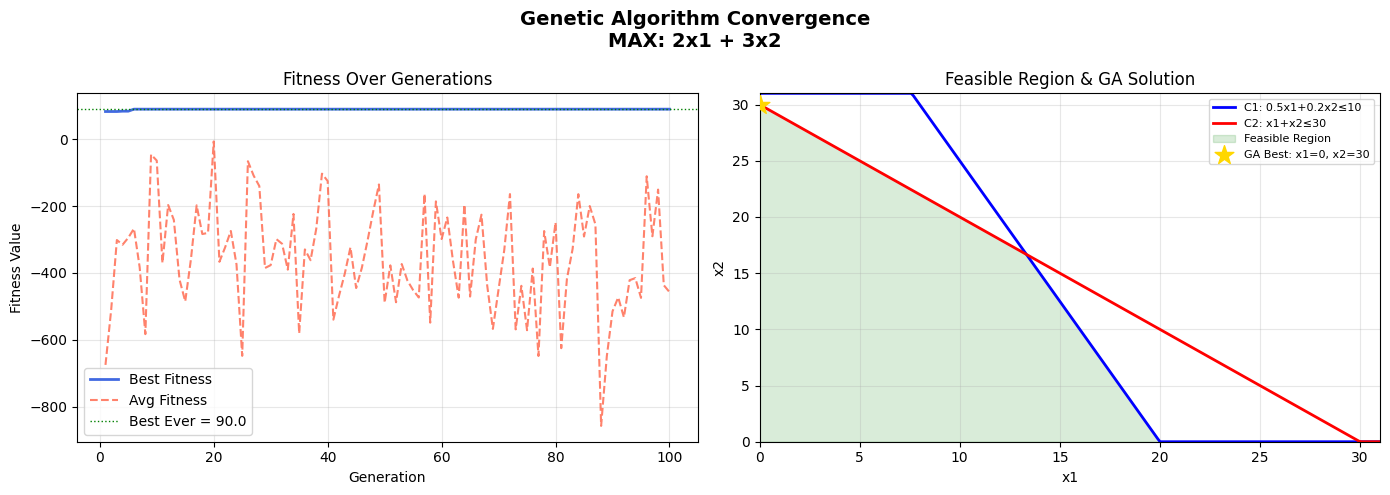


 สรุป: GA หาคำตอบได้ที่ x1=0, x2=30, Objective=90


In [ ]:
# ============================================================
# Plot: Convergence Graph
# ============================================================
generations_list = list(range(1, GENERATION_MAX + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Genetic Algorithm Convergence\nMAX: 2x1 + 3x2',
             fontsize=14, fontweight='bold')

# --- กราฟที่ 1: Best Fitness vs Average Fitness ---
ax1 = axes[0]
ax1.plot(generations_list, best_fitness_history,
         color='royalblue', linewidth=2, label='Best Fitness')
ax1.plot(generations_list, avg_fitness_history,
         color='tomato', linewidth=1.5, linestyle='--', label='Avg Fitness', alpha=0.8)
ax1.axhline(y=best_fitness_ever, color='green', linewidth=1,
            linestyle=':', label=f'Best Ever = {best_fitness_ever:.1f}')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Fitness Value')
ax1.set_title('Fitness Over Generations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- กราฟที่ 2: Feasible Region (ถ้าคำตอบ Feasible) ---
ax2 = axes[1]

# วาด Feasible Region
x1_range = np.linspace(0, 31, 300)

# C1: 0.5x1 + 0.2x2 <= 10 → x2 <= (10 - 0.5x1) / 0.2
c1_x2 = (10 - 0.5 * x1_range) / 0.2
# C2: x1 + x2 <= 30 → x2 <= 30 - x1
c2_x2 = 30 - x1_range

# วาด Constraint boundaries
ax2.plot(x1_range, np.clip(c1_x2, 0, 31), 'b-', linewidth=2,
         label='C1: 0.5x1+0.2x2≤10')
ax2.plot(x1_range, np.clip(c2_x2, 0, 31), 'r-', linewidth=2,
         label='C2: x1+x2≤30')

# แรเงา Feasible Region
x2_feasible = np.minimum(np.clip(c1_x2, 0, 31), np.clip(c2_x2, 0, 31))
ax2.fill_between(x1_range, 0, x2_feasible, alpha=0.15, color='green',
                 label='Feasible Region')

# วาดคำตอบที่ GA หาได้
ax2.scatter(best_x1, best_x2, color='gold', s=200, zorder=5,
            marker='*', label=f'GA Best: x1={best_x1}, x2={best_x2}')

ax2.set_xlim(0, 31)
ax2.set_ylim(0, 31)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Feasible Region & GA Solution')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n สรุป: GA หาคำตอบได้ที่ x1={best_x1}, x2={best_x2}, Objective={best_obj}")

## 🔬 ส่วนที่ 13: Sensitivity Analysis — ทดสอบ Parameters

ทดลองเปลี่ยน Parameters เพื่อดูผลกระทบต่อการหาคำตอบ

In [ ]:
def run_ga(pop_size=20, xover_rate=0.8, mutation_rate=None,
           generation_max=100, n_runs=5, seed_start=0):
    """
    ฟังก์ชัน wrapper สำหรับรัน GA หลายครั้งและคืนค่าเฉลี่ย
    ใช้สำหรับ Sensitivity Analysis
    """
    if mutation_rate is None:
        mutation_rate = 1 / N_BITS

    n_offspring = int(pop_size * xover_rate)
    n_elite = pop_size - n_offspring

    all_best = []

    for run in range(n_runs):
        random.seed(seed_start + run)

        pop = initialize_population(pop_size, CHROMOSOME_LEN)
        best_fit = float('-inf')

        for _ in range(generation_max):
            # สร้าง Offspring
            offspring_pool = []
            while len(offspring_pool) < n_offspring:
                p1, p2 = parent_selection(pop)
                o1, o2 = crossover(p1, p2)
                o1 = mutate(o1, mutation_rate)
                o2 = mutate(o2, mutation_rate)
                offspring_pool.append(o1)
                if len(offspring_pool) < n_offspring:
                    offspring_pool.append(o2)

            # Elitism Selection
            pop = elitism_selection(pop, offspring_pool, n_elite)

            # หา Best
            for chrom in pop:
                f = calculate_fitness(chrom)
                if f > best_fit:
                    best_fit = f

        all_best.append(best_fit)

    return np.mean(all_best), np.std(all_best)


# ===== ทดสอบ Population Size ต่างๆ =====
print("🔬 Sensitivity Analysis: ผลของ Population Size")
print("-" * 50)
print(f"{'Pop Size':>10} | {'Avg Best Fitness':>18} | {'Std Dev':>8}")
print("-" * 50)

for pop_size in [10, 20, 50, 100]:
    mean_fit, std_fit = run_ga(pop_size=pop_size, n_runs=5)
    print(f"  {pop_size:8d} | {mean_fit:18.2f} | {std_fit:8.2f}")

print()
print("🔬 Sensitivity Analysis: ผลของ Mutation Rate")
print("-" * 50)
print(f"{'Mut Rate':>10} | {'Avg Best Fitness':>18} | {'Std Dev':>8}")
print("-" * 50)

for mut_rate in [0.05, 0.10, 0.20, 0.40, 0.50]:
    mean_fit, std_fit = run_ga(mutation_rate=mut_rate, n_runs=5)
    print(f"  {mut_rate:8.2f} | {mean_fit:18.2f} | {std_fit:8.2f}")

🔬 Sensitivity Analysis: ผลของ Population Size
--------------------------------------------------
  Pop Size |   Avg Best Fitness |  Std Dev
--------------------------------------------------
        10 |              90.00 |     0.00
        20 |              89.80 |     0.40
        50 |              90.00 |     0.00
       100 |              90.00 |     0.00

🔬 Sensitivity Analysis: ผลของ Mutation Rate
--------------------------------------------------
  Mut Rate |   Avg Best Fitness |  Std Dev
--------------------------------------------------
      0.05 |              88.60 |     1.36
      0.10 |              89.40 |     0.80
      0.20 |              89.80 |     0.40
      0.40 |              89.80 |     0.40
      0.50 |              89.60 |     0.49


## 📝 ส่วนที่ 14: สรุปและแบบฝึกหัด

---

###  สรุป Genetic Algorithm ที่ใช้ในบทเรียนนี้

| ขั้นตอน | วิธีที่ใช้ | Parameter |
|--------|-----------|----------|
| Encoding | Binary (5 bits/ตัวแปร) | N_BITS = 5 |
| Fitness | Objective - Penalty×Violation | W = 100 |
| Selection | Binary Tournament | - |
| Crossover | One-Point Crossover | XOVER_RATE = 0.8 |
| Mutation | Bit Flip | MUTATION_RATE = 1/5 |
| Survivor | Elitism (20% Elite) | ELITE_RATE = 0.2 |

---

###  แบบฝึกหัด: พัฒนา GA ให้ดีขึ้น

1. **เปลี่ยน Encoding** → ลอง Real-valued encoding แทน Binary

2. **เปลี่ยน Crossover** → ลอง Two-Point Crossover หรือ Uniform Crossover

3. **เปลี่ยน Selection** → ลอง Roulette Wheel Selection หรือ Rank Selection

4. **เพิ่มตัวแปร** → แก้ไขโจทย์ให้มี x1, x2, x3 (3 ตัวแปร)

5. **Adaptive Mutation** → ให้ Mutation Rate ลดลงตาม Generation

6. **Multi-objective** → เพิ่ม Objective Function ที่สอง เช่น MIN: x1 + x2

---

### 💡 คำถามทบทวน

1. ทำไม Elitism ถึงช่วยให้ GA ลู่เข้าสู่คำตอบที่ดีได้เร็วขึ้น?
2. Mutation Rate ที่สูงเกินไปจะมีผลอย่างไรต่อ GA?
3. Binary Tournament เหมาะกับปัญหาแบบใด เมื่อเทียบกับ Roulette Wheel?
4. หาก Penalty Weight ต่ำเกินไป จะเกิดอะไรขึ้น?